# Counterfactual vs Vanilla GRPO on Financial Reasoning (Qwen3-1.7B)

This notebook compares **Counterfactual GRPO** against **Vanilla GRPO** for financial arithmetic reasoning.

**Setup:**
- Base model: `Qwen/Qwen3-1.7B` with LoRA (r=32)
- Training data: TAT-QA arithmetic (2,000) + FinanceReasoning medium train half (496) = 2,496 examples
- Reward: binary numeric comparison (correct/incorrect answer)
- G=8 generations per prompt, batch_size=16
- lr=1.5e-5, DAPO loss, 500 steps, checkpoints every 100 steps
- Evaluation: TAT-QA test (630), FinanceReasoning medium test (496)

**Runs:**
- **CF nocons** (0.15–2.0): counterfactual token weighting, no gradient conservation
- **Vanilla**: uniform token weighting (standard GRPO)
- **CF conserved** (0.5–2.0): counterfactual weighting with gradient conservation (mean=1.0)

## Why Financial Arithmetic Reasoning?

Large language models struggle with **multi-step numerical reasoning over financial data** — extracting the right numbers from tables or context, choosing the correct operation, and computing accurately. This is a high-value capability for financial analysis automation.

### Example Problems

**TAT-QA** (Table-and-Text Question Answering) — arithmetic over real financial filings:

> **Context:** *"The total remuneration of PricewaterhouseCoopers LLP for services provided during the year ended 31 March 2019: Audit fees £19M (2018), £26M (2019)..."*
>
> **Question:** What is the average audit fee across 2018 and 2019?
>
> **Answer:** (19 + 26) / 2 = **22.5 million**

> **Context:** *"Net income for fiscal year ended Feb 28, 2018 was $16.6M. Operating expenses: $48,943K + $8,233K..."*
>
> **Question:** What are total operating expenses in thousands?
>
> **Answer:** 48,943 + 8,233 = **57,176 thousand**

**FinanceReasoning Medium** — synthetic financial word problems:

> *An individual has invested in a corporate bond with a principal amount of $100,000. The bond offers an annual interest rate of 5.25%. Calculate accrued interest after 90 days using the 30/360 convention.*
>
> **Answer:** 100,000 × 0.0525 × (90/360) = **$1,312.50**

### The Challenge for Standard GRPO

Standard (vanilla) GRPO treats all tokens in a correct response equally. But in financial reasoning, **not all tokens matter equally for getting the right answer:**

| Token Type | Example | Importance |
|---|---|---|
| Data extraction | *"Audit fees: £19M (2018), £26M (2019)"* | **Critical** — wrong numbers → wrong answer |
| Arithmetic | *"(19 + 26) / 2 = 22.5"* | **Critical** — wrong operation → wrong answer |
| Formatting | *"### Step 1:", "---", "\$\$"* | Low — doesn't affect correctness |
| Filler text | *"Let me calculate...", "We need to..."* | Low — boilerplate phrasing |

**Counterfactual GRPO** addresses this by assigning per-token gradient weights based on measured causal importance: masking each reasoning span and measuring how much the answer probability drops.

## 1. Setup

In [ ]:
import os, sys, json, re, subprocess, gc
os.chdir('/home/jovyan/Finetunehub')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch
from pathlib import Path
from datasets import load_from_disk

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

os.environ['CUDA_VISIBLE_DEVICES'] = '1'

# Base model scores (no fine-tuning)
BASE_TATQA = 0.4698
BASE_FINMED = 0.3952

def run_training(config_path, log_path):
    """Run training via run_tatqa_train.py and return exit code."""
    print(f'Starting training: {config_path}')
    with open(log_path, 'w') as log_f:
        proc = subprocess.run(
            [sys.executable, 'run_tatqa_train.py', '--config', config_path],
            stdout=log_f, stderr=subprocess.STDOUT
        )
    print(f'Training finished (exit code {proc.returncode})')
    with open(log_path) as f:
        lines = f.readlines()
        for line in lines[-5:]:
            print(line.rstrip())
    return proc.returncode

def run_eval(model_path, lora_path, data_dir, output_dir,
             eval_script='scripts/eval_finance_reasoning.py', max_tokens=2500):
    """Run evaluation and return (accuracy, correct, total)."""
    cmd = [sys.executable, eval_script,
           '--model_path', model_path,
           '--output_dir', output_dir,
           '--temperature', '0.0',
           '--max_tokens', str(max_tokens)]
    if lora_path:
        cmd += ['--lora_path', lora_path]
    if 'finance' in eval_script:
        cmd += ['--data_dir', data_dir]
    result = subprocess.run(cmd, capture_output=True, text=True)
    for line in result.stdout.split('\n'):
        if 'Accuracy:' in line:
            m = re.search(r'Accuracy: ([0-9.]+) \((\d+)/(\d+)\)', line)
            if m:
                return float(m.group(1)), int(m.group(2)), int(m.group(3))
    return None, None, None

def cleanup():
    gc.collect()
    torch.cuda.empty_cache()

print('Setup complete.')

In [2]:
from datasets import load_from_disk

# Verify datasets
tatqa = load_from_disk('data/tatqa_arithmetic')
print(f'TAT-QA arithmetic: {len(tatqa):,} train examples')
print(f'  Columns: {tatqa.column_names}')
print(f'  Example Q: {tatqa[0]["question"][:40]}...')
print(f'  Example A: {tatqa[0]["answer"]}')

finmed = load_from_disk('data/finance_reasoning_medium')
print(f'\nFinanceReasoning medium: {len(finmed["train"])} train / {len(finmed["test"])} test')
print(f'  Columns: {finmed["train"].column_names}')

combined = load_from_disk('data/combined_tatqa_finreason')
print(f'\nCombined training set: {len(combined["train"]):,} examples (TAT-QA: {len(tatqa)}, FinReason: {len(finmed["train"])})')


TAT-QA arithmetic: 2,000 train examples
  Columns: ['question', 'answer', 'derivation', 'scale', 'answer_from']
  Example Q: 3.6 PROFIT FOR THE YEAR
(1) Fiscal 2018 ...
  Example A: -0.72

FinanceReasoning medium: 496 train / 496 test
  Columns: ['question', 'answer', 'source', 'difficulty', 'level', 'question_id']

Combined training set: 2,496 examples (TAT-QA: 2000, FinReason: 496)


## 2. Training

Train both models with identical hyperparameters, differing only in `weighting_mode`.
Each run takes ~3.5–4.5 hours on an L40S GPU.

**Skip this section** if checkpoints already exist at `output/qwen3_counterfact_combined_nocons2/` and `output/qwen3_vanilla_combined/`.

In [11]:
# Train counterfactual GRPO (~4 hours on L40S)
# Skip if output/qwen3_counterfact_combined_nocons2/checkpoint-500 already exists
if not Path('output/qwen3_counterfact_combined_nocons2/checkpoint-500').exists():
    run_training('configs/qwen3_1.7b_combined_counterfact_nocons2.yaml', '/tmp/nb_cf_nocons2.log')
else:
    print('CF checkpoints found, skipping training.')


Starting training: configs/qwen3_1.7b_combined_counterfact_nocons2.yaml
Training finished (exit code 0)
Training time: 13128.14 seconds
Final loss: -0.0049
Model saved to: output/qwen3_counterfact_combined_nocons2


In [12]:
# Train vanilla GRPO (~4 hours on L40S)
# Skip if output/qwen3_vanilla_combined/checkpoint-500 already exists
if not Path('output/qwen3_vanilla_combined/checkpoint-500').exists():
    run_training('configs/qwen3_1.7b_combined_vanilla.yaml', '/tmp/nb_vanilla.log')
else:
    print('Vanilla checkpoints found, skipping training.')


Starting training: configs/qwen3_1.7b_combined_vanilla.yaml
Training finished (exit code 0)
Training time: 12455.02 seconds
Final loss: 0.0041
Model saved to: output/qwen3_vanilla_combined


## 3. Evaluation

Evaluate all checkpoints on both benchmarks using vLLM.
**Skip this section** if `eval_results/nocons2_cf_med_500/results.json` already exists.

In [13]:
MODEL = 'Qwen/Qwen3-1.7B'
steps = [100, 200, 300, 400, 500]

print('Evaluating on FinanceReasoning Medium (496 test examples)...')
print()
print(f'{"Model":<30} {"Step":>6} {"Accuracy":>10} {"Correct":>8} {"Total":>6}')
print('-' * 65)

# Baseline
acc, c, t = run_eval(MODEL, None, 'data/finance_reasoning_medium', 'eval_results/nb_base_med')
print(f'{"Baseline (Qwen3-1.7B)":<30} {"—":>6} {acc:>10.4f} {c:>8} {t:>6}')

# CF nocons checkpoints
for step in steps:
    lora = f'output/qwen3_counterfact_combined_nocons2/checkpoint-{step}'
    acc, c, t = run_eval(MODEL, lora, 'data/finance_reasoning_medium', f'eval_results/nocons2_cf_med_{step}')
    print(f'{"CF nocons (0.15-2.0)":<30} {step:>6} {acc:>10.4f} {c:>8} {t:>6}')

# Vanilla checkpoints
for step in steps:
    lora = f'output/qwen3_vanilla_combined/checkpoint-{step}'
    acc, c, t = run_eval(MODEL, lora, 'data/finance_reasoning_medium', f'eval_results/b16_van_med_{step}')
    print(f'{"Vanilla GRPO":<30} {step:>6} {acc:>10.4f} {c:>8} {t:>6}')

cleanup()


Evaluating on FinanceReasoning Medium (496 test examples)...

Model                            Step   Accuracy  Correct  Total
-----------------------------------------------------------------
Baseline (Qwen3-1.7B)               —     0.3952      196    496
CF nocons (0.15-2.0)              100     0.4012      199    496
CF nocons (0.15-2.0)              200     0.4052      201    496
CF nocons (0.15-2.0)              300     0.4032      200    496
CF nocons (0.15-2.0)              400     0.4234      210    496
CF nocons (0.15-2.0)              500     0.4294      213    496
Vanilla GRPO                      100     0.3871      192    496
Vanilla GRPO                      200     0.3710      184    496
Vanilla GRPO                      300     0.3891      193    496
Vanilla GRPO                      400     0.3810      189    496
Vanilla GRPO                      500     0.4012      199    496


In [ ]:
print('Evaluating on TAT-QA arithmetic (630 test examples)...')
print()
print(f'{"Model":<30} {"Step":>6} {"Accuracy":>10} {"Correct":>8} {"Total":>6}')
print('-' * 65)

# Baseline
acc, c, t = run_eval(MODEL, None, None, 'eval_results/nb_base_tatqa', eval_script='scripts/eval_tatqa.py')
print(f'{"Baseline (Qwen3-1.7B)":<30} {"—":>6} {acc:>10.4f} {c:>8} {t:>6}')

# CF nocons checkpoints
for step in steps:
    lora = f'output/qwen3_counterfact_combined_nocons2/checkpoint-{step}'
    acc, c, t = run_eval(MODEL, lora, None, f'eval_results/nocons2_cf_tatqa_{step}', eval_script='scripts/eval_tatqa.py')
    print(f'{"CF nocons (0.15-2.0)":<30} {step:>6} {acc:>10.4f} {c:>8} {t:>6}')

# Vanilla & conserved final
for name, lora in [('Vanilla GRPO', 'output/qwen3_vanilla_combined'),
                   ('CF conserved (0.5-2.0)', 'output/qwen3_counterfact_combined')]:
    acc, c, t = run_eval(MODEL, lora, None, f'eval_results/nb_{name}_tatqa', eval_script='scripts/eval_tatqa.py')
    print(f'{name:<30} {500:>6} {acc:>10.4f} {c:>8} {t:>6}')

cleanup()

## 4. Analysis

In [ ]:
# Load evaluation results from saved JSON files
def load_eval_curve(prefix, steps, suffix='results.json'):
    accs = []
    valid_steps = []
    for s in steps:
        p = Path(f'eval_results/{prefix}_{s}/{suffix}')
        if p.exists():
            with open(p) as f:
                d = json.load(f)
            accs.append(d['accuracy'])
            valid_steps.append(s)
    return np.array(valid_steps), np.array(accs)

# Load training logs from trainer_state.json
def load_training_logs(output_dir, max_step=None):
    checkpoints = sorted(Path(output_dir).glob('checkpoint-*'), key=lambda p: int(p.name.split('-')[1]))
    state_file = checkpoints[-1] / 'trainer_state.json'
    with open(state_file) as f:
        state = json.load(f)
    logs = state['log_history']
    if max_step:
        logs = [e for e in logs if e.get('step', 0) <= max_step]
    return logs

steps = list(range(100, 600, 100))

# CF nocons2 (0.15-2.0) — best variant
cf2_steps, cf2_med = load_eval_curve('nocons2_cf_med', steps)
_, cf2_tatqa = load_eval_curve('nocons2_cf_tatqa', steps)

# CF nocons (0.5-4.0)
cf1_steps, cf1_med = load_eval_curve('nocons_cf_med', steps)
_, cf1_tatqa = load_eval_curve('nocons_cf_tatqa', steps)

# CF conserved (0.5-2.0)
cons_steps, cons_med = load_eval_curve('b16_cf_med', steps)
_, cons_tatqa = load_eval_curve('b16_cf_tatqa', steps)

# Vanilla
van_steps, van_med = load_eval_curve('b16_van_med', steps)
_, van_tatqa = load_eval_curve('b16_van_tatqa', steps)

# Training logs
cf_logs = load_training_logs('output/qwen3_counterfact_combined_nocons2')
van_logs = load_training_logs('output/qwen3_vanilla_combined')

print(f'CF nocons2 (0.15-2.0):  {len(cf2_steps)} checkpoints — FinR-Med + TAT-QA')
print(f'CF nocons  (0.5-4.0):   {len(cf1_steps)} checkpoints — FinR-Med + TAT-QA')
print(f'CF conserved (0.5-2.0): {len(cons_steps)} checkpoints — FinR-Med + TAT-QA')
print(f'Vanilla:                {len(van_steps)} checkpoints — FinR-Med + TAT-QA')

CF nocons2 (0.15-2.0):  5 checkpoints — FinR-Med + TAT-QA
CF nocons  (0.5-4.0):   5 checkpoints — FinR-Med + TAT-QA
CF conserved (0.5-2.0): 5 checkpoints — FinR-Med + TAT-QA
Vanilla:                5 checkpoints — FinR-Med + TAT-QA


### Evaluation Curves

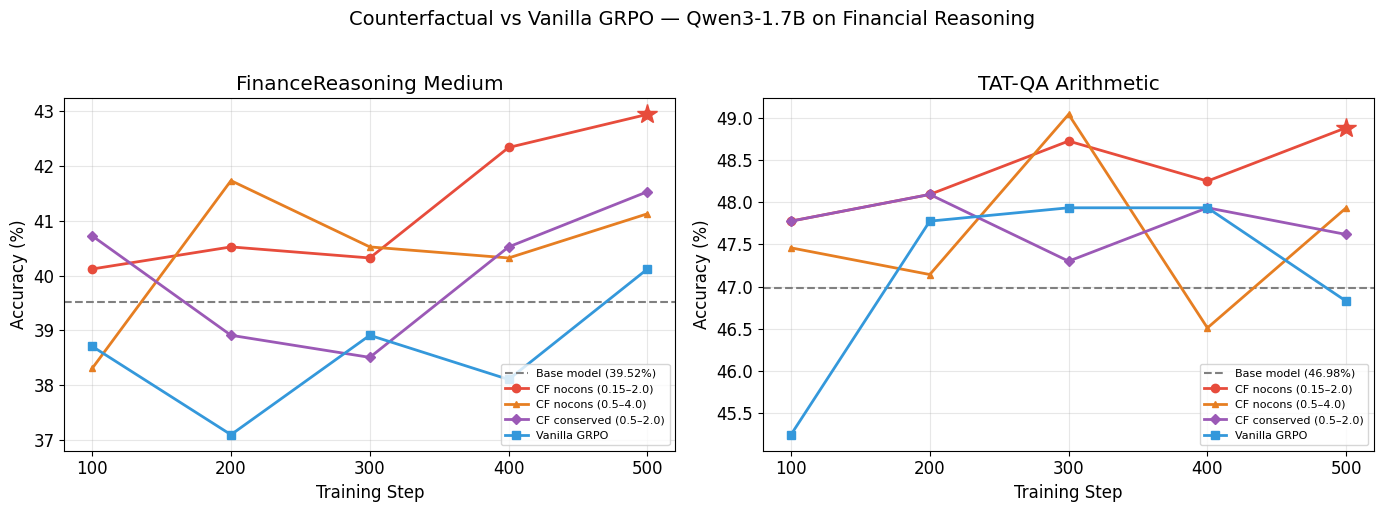


Best CF nocons2: step 500 — FinR-Med 0.4294, TAT-QA 0.4889
Best Vanilla:    step 500 — FinR-Med 0.4012, TAT-QA 0.4794
Base model:                FinR-Med 0.3952, TAT-QA 0.4698


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Colors
C_CF2 = '#e74c3c'   # nocons2 (0.15-2.0) — red
C_CF1 = '#e67e22'   # nocons  (0.5-4.0) — orange
C_CON = '#9b59b6'   # conserved (0.5-2.0) — purple
C_VAN = '#3498db'   # vanilla — blue

# Left: FinanceReasoning Medium
ax = axes[0]
ax.axhline(BASE_FINMED * 100, color='gray', linestyle='--', linewidth=1.5, label=f'Base model ({BASE_FINMED:.2%})')
ax.plot(cf2_steps, cf2_med * 100, 'o-', color=C_CF2, linewidth=2, markersize=6, label='CF nocons (0.15–2.0)')
ax.plot(cf1_steps, cf1_med * 100, '^-', color=C_CF1, linewidth=2, markersize=5, label='CF nocons (0.5–4.0)')
ax.plot(cons_steps, cons_med * 100, 'D-', color=C_CON, linewidth=2, markersize=5, label='CF conserved (0.5–2.0)')
ax.plot(van_steps, van_med * 100, 's-', color=C_VAN, linewidth=2, markersize=6, label='Vanilla GRPO')

best_i = int(np.argmax(cf2_med))
ax.plot(cf2_steps[best_i], cf2_med[best_i] * 100, '*', color=C_CF2, markersize=15, zorder=5)

ax.set_xlabel('Training Step')
ax.set_ylabel('Accuracy (%)')
ax.set_title('FinanceReasoning Medium')
ax.legend(loc='lower right', fontsize=8)
ax.set_xticks([100, 200, 300, 400, 500])

# Right: TAT-QA
ax = axes[1]
ax.axhline(BASE_TATQA * 100, color='gray', linestyle='--', linewidth=1.5, label=f'Base model ({BASE_TATQA:.2%})')
ax.plot(cf2_steps, cf2_tatqa * 100, 'o-', color=C_CF2, linewidth=2, markersize=6, label='CF nocons (0.15–2.0)')
ax.plot(cf1_steps, cf1_tatqa * 100, '^-', color=C_CF1, linewidth=2, markersize=5, label='CF nocons (0.5–4.0)')
ax.plot(cons_steps, cons_tatqa * 100, 'D-', color=C_CON, linewidth=2, markersize=5, label='CF conserved (0.5–2.0)')
ax.plot(van_steps, van_tatqa * 100, 's-', color=C_VAN, linewidth=2, markersize=6, label='Vanilla GRPO')

best_t = int(np.argmax(cf2_tatqa))
ax.plot(cf2_steps[best_t], cf2_tatqa[best_t] * 100, '*', color=C_CF2, markersize=15, zorder=5)

ax.set_xlabel('Training Step')
ax.set_ylabel('Accuracy (%)')
ax.set_title('TAT-QA Arithmetic')
ax.legend(loc='lower right', fontsize=8)
ax.set_xticks([100, 200, 300, 400, 500])

fig.suptitle('Counterfactual vs Vanilla GRPO — Qwen3-1.7B on Financial Reasoning', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plots/cf_vs_vanilla_finance_eval.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nBest CF nocons2: step {cf2_steps[best_i]:>3d} — FinR-Med {cf2_med[best_i]:.4f}, TAT-QA {cf2_tatqa[best_t]:.4f}')
print(f'Best Vanilla:    step {van_steps[int(np.argmax(van_med))]:>3d} — FinR-Med {van_med.max():.4f}, TAT-QA {van_tatqa.max():.4f}')
print(f'Base model:                FinR-Med {BASE_FINMED:.4f}, TAT-QA {BASE_TATQA:.4f}')

### Training Dynamics

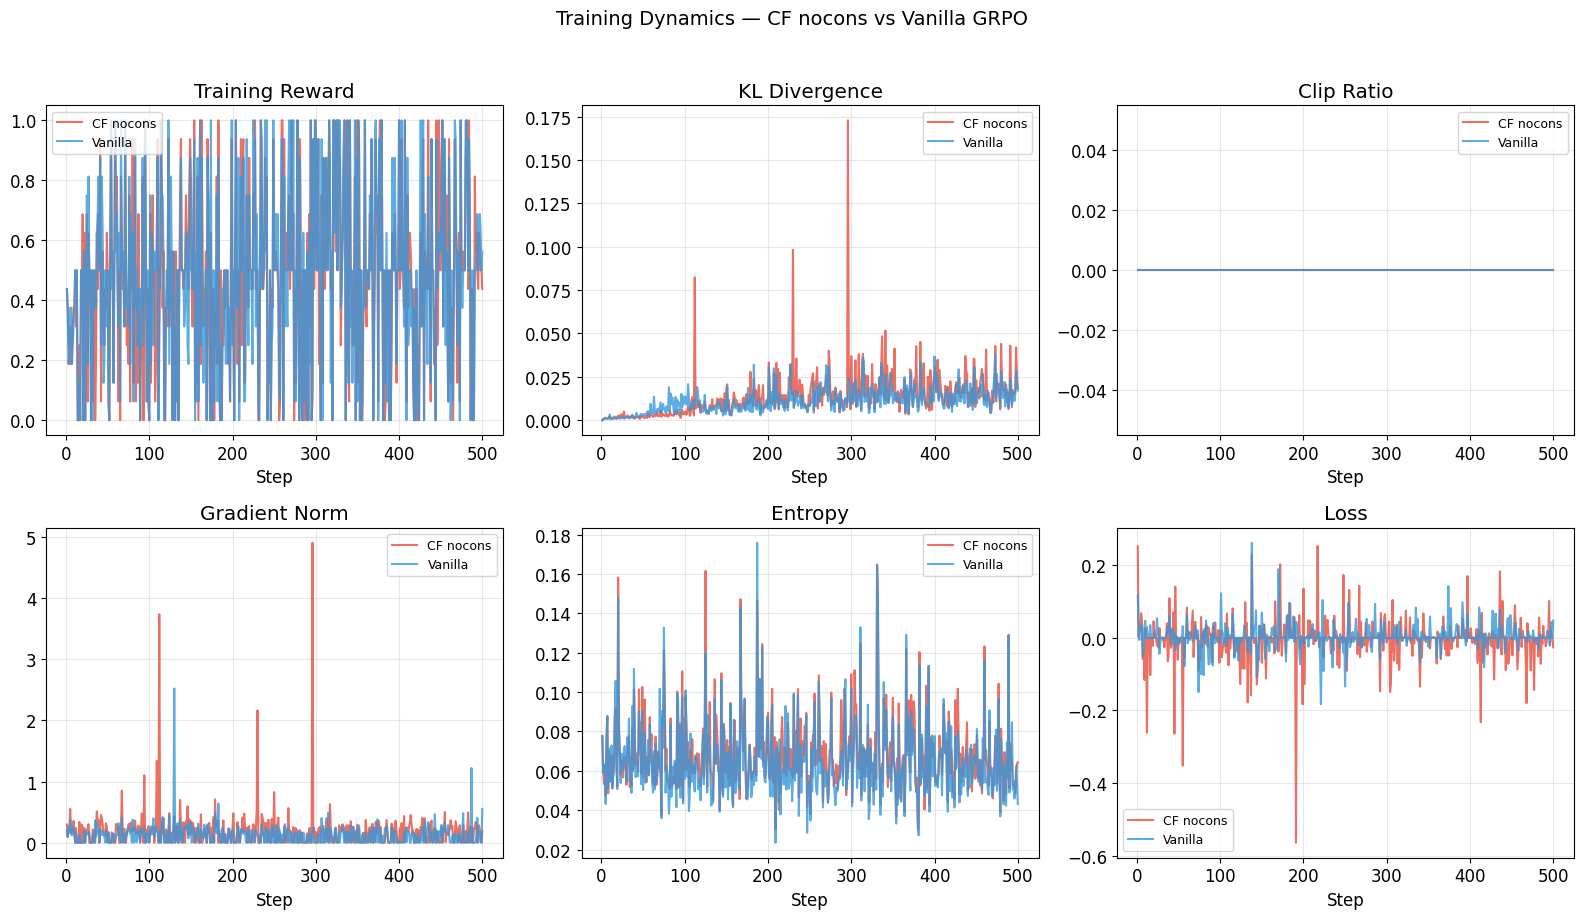

In [5]:
def extract_metric(logs, key):
    steps, vals = [], []
    for entry in logs:
        if key in entry:
            steps.append(entry['step'])
            vals.append(entry[key])
    return np.array(steps), np.array(vals)

metrics = [
    ('reward', 'Training Reward'),
    ('kl', 'KL Divergence'),
    ('clip_ratio/region_mean', 'Clip Ratio'),
    ('grad_norm', 'Gradient Norm'),
    ('entropy', 'Entropy'),
    ('loss', 'Loss'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (key, title) in zip(axes, metrics):
    cs, cv = extract_metric(cf_logs, key)
    vs, vv = extract_metric(van_logs, key)

    ax.plot(cs, cv, '-', color='#e74c3c', linewidth=1.5, alpha=0.8, label='CF nocons')
    ax.plot(vs, vv, '-', color='#3498db', linewidth=1.5, alpha=0.8, label='Vanilla')
    ax.set_title(title)
    ax.set_xlabel('Step')
    ax.legend(fontsize=9)

fig.suptitle('Training Dynamics — CF nocons vs Vanilla GRPO', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plots/cf_vs_vanilla_finance_training.png', dpi=150, bbox_inches='tight')
plt.show()


### Counterfactual Weight Analysis

Counterfactual GRPO assigns per-token gradient weights based on **counterfactual importance**:
1. Detect calculation spans in correct completions (numbers, formulas, equations)
2. Mask each span and measure the drop in answer probability
3. High-drop spans get higher weight (up to 2.0x), low-drop spans get lower weight (down to 0.15x)
4. **No gradient conservation**: mean weight > 1.0, so important tokens also get amplified total gradient

In [6]:
# Extract weight statistics from training
cf_weight_steps, cf_weight_means = extract_metric(cf_logs, 'counterfact/weight_mean')
_, cf_weight_stds = extract_metric(cf_logs, 'counterfact/weight_std')
_, cf_weight_mins = extract_metric(cf_logs, 'counterfact/weight_min')
_, cf_weight_maxs = extract_metric(cf_logs, 'counterfact/weight_max')

print(f'Counterfactual weight statistics ({len(cf_weight_means)} training steps):')
print(f'  Mean weight:  {cf_weight_means.mean():.4f} ± {cf_weight_means.std():.4f}  (no conservation → not normalized to 1.0)')
print(f'  Weight std:   {cf_weight_stds.mean():.4f} ± {cf_weight_stds.std():.4f}')
print(f'  Min weight:   {cf_weight_mins.mean():.4f} (floor: 0.15)')
print(f'  Max weight:   {cf_weight_maxs.mean():.4f} (cap: 2.0)')
print(f'  Spread:       {(cf_weight_maxs - cf_weight_mins).mean():.4f}')
print()
print('Interpretation:')
print(f'  Important tokens (data extraction, calculations) get {cf_weight_maxs.mean():.1f}x gradient weight')
print(f'  Unimportant tokens (boilerplate, filler) get {cf_weight_mins.mean():.1f}x gradient weight')
print(f'  Ratio: {cf_weight_maxs.mean()/cf_weight_mins.mean():.1f}x difference between most/least important')
print(f'  Mean gradient amplification: {cf_weight_means.mean():.2f}x (vs 1.0x for vanilla)')


Counterfactual weight statistics (299 training steps):
  Mean weight:  1.3055 ± 0.0782  (no conservation → not normalized to 1.0)
  Weight std:   0.4689 ± 0.0489
  Min weight:   0.1503 (floor: 0.15)
  Max weight:   2.0000 (cap: 2.0)
  Spread:       1.8497

Interpretation:
  Important tokens (data extraction, calculations) get 2.0x gradient weight
  Unimportant tokens (boilerplate, filler) get 0.2x gradient weight
  Ratio: 13.3x difference between most/least important
  Mean gradient amplification: 1.31x (vs 1.0x for vanilla)


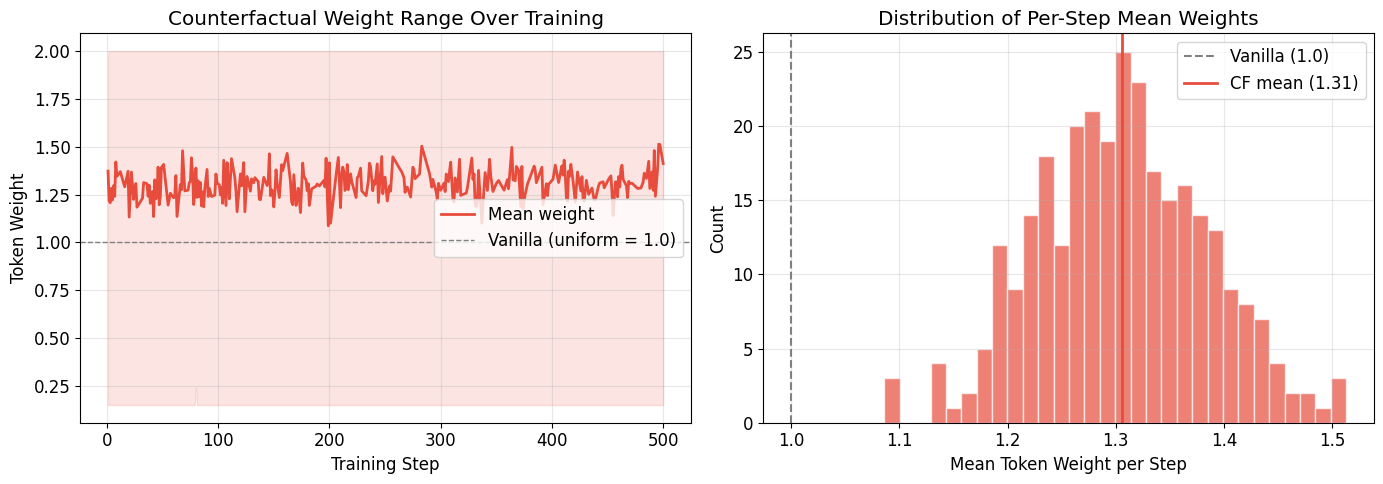

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Weight distribution over training
ax = axes[0]
ax.fill_between(cf_weight_steps, cf_weight_mins, cf_weight_maxs, alpha=0.15, color='#e74c3c')
ax.plot(cf_weight_steps, cf_weight_means, '-', color='#e74c3c', linewidth=2, label='Mean weight')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='Vanilla (uniform = 1.0)')
ax.set_xlabel('Training Step')
ax.set_ylabel('Token Weight')
ax.set_title('Counterfactual Weight Range Over Training')
ax.legend()

# Right: Mean weight histogram
ax = axes[1]
ax.hist(cf_weight_means, bins=30, color='#e74c3c', alpha=0.7, edgecolor='white')
ax.axvline(1.0, color='gray', linestyle='--', linewidth=1.5, label='Vanilla (1.0)')
ax.axvline(cf_weight_means.mean(), color='#e74c3c', linestyle='-', linewidth=2,
           label=f'CF mean ({cf_weight_means.mean():.2f})')
ax.set_xlabel('Mean Token Weight per Step')
ax.set_ylabel('Count')
ax.set_title('Distribution of Per-Step Mean Weights')
ax.legend()

plt.tight_layout()
plt.savefig('plots/cf_weight_analysis_nocons.png', dpi=150, bbox_inches='tight')
plt.show()


### What Spans Does Counterfactual GRPO Focus On?

The counterfactual importance mechanism works in two stages:
1. **Span detection** — identify arithmetic expressions (`48943 + 8233 = 57176`) and sentence-level reasoning spans in the model's chain-of-thought
2. **Counterfactual masking** — for each span, mask it out and measure how much the **final answer probability drops**

Spans where masking causes a large probability drop are causally important for the answer and get high gradient weight (up to **2.0x**). Spans where masking barely affects the answer get suppressed (down to **0.15x**).

Below we show real span-level counterfactual weights from running the trained model on test examples.

In [ ]:
# Load span analysis results (pre-computed by running counterfactual importance on test examples)
with open('notebooks/span_analysis_data.json') as f:
    span_data = json.load(f)

print(f"Loaded counterfactual span analysis for {len(span_data)} examples\n")

# ── Display span-level counterfactual weights ────────────────────────────
TYPE_COLORS = {
    'arithmetic':      '\033[91m',   # red
    'data_extraction': '\033[93m',   # yellow
    'reasoning':       '\033[92m',   # green
    'formatting':      '\033[90m',   # gray
}
RESET = '\033[0m'

for ex in span_data:
    print(f'{"="*75}')
    print(f'[{ex["benchmark"]}]  Gold answer: {ex["gold"]}')
    print(f'Tokens: {ex["total_len"]} total ({ex["prompt_len"]} prompt + '
          f'{ex["total_len"] - ex["prompt_len"]} generation)')
    print(f'Weight stats: mean={ex["weight_stats"]["mean"]:.3f}, '
          f'range=[{ex["weight_stats"]["min"]:.3f}, {ex["weight_stats"]["max"]:.3f}]')
    print(f'{"="*75}')
    print(f'{"Rank":>4}  {"Weight":>7}  {"Type":>14}  {"Span Text"}')
    print(f'{"-"*4}  {"-"*7}  {"-"*14}  {"-"*45}')
    
    for i, sp in enumerate(ex['spans']):
        # Visual weight bar
        bar_len = int(sp['weight'] / 2.0 * 15)
        bar = '█' * bar_len + '░' * (15 - bar_len)
        
        color = TYPE_COLORS.get(sp['type'], '')
        text = sp['text'].replace('\n', ' ').strip()[:55]
        
        print(f'{i+1:4d}  {sp["weight"]:7.3f}  {color}{sp["type"]:>14s}{RESET}  |{bar}| {text}')
    
    print()

# ── Key observation ──────────────────────────────────────────────────────
all_spans = [sp for ex in span_data for sp in ex['spans']]
high_w = [sp for sp in all_spans if sp['weight'] >= 1.5]
low_w = [sp for sp in all_spans if sp['weight'] < 1.0]
mid_w = [sp for sp in all_spans if 1.0 <= sp['weight'] < 1.5]

print(f'Across {len(span_data)} examples ({len(all_spans)} total spans):')
print(f'  High-weight spans (≥1.5x): {len(high_w)}/{len(all_spans)} '
      f'({len(high_w)/len(all_spans)*100:.0f}%)')
print(f'  Mid-weight spans (1.0-1.5x): {len(mid_w)}/{len(all_spans)} '
      f'({len(mid_w)/len(all_spans)*100:.0f}%)')
print(f'  Low-weight spans (<1.0x): {len(low_w)}/{len(all_spans)} '
      f'({len(low_w)/len(all_spans)*100:.0f}%)')

Loaded counterfactual span analysis for 6 examples

[FinReason]  Gold answer: 800.0
Tokens: 728 total (260 prompt + 468 generation)
Weight stats: mean=1.082, range=[0.242, 2.000]
Rank   Weight            Type  Span Text
----  -------  --------------  ---------------------------------------------
   1    1.722      formatting  |████████████░░░| ### **Given Data:**
   2    1.132       reasoning  |████████░░░░░░░| $$ \text{Net Pension Expense} = 350 + 3,100 - 1,200 = 2
   3    1.113       reasoning  |████████░░░░░░░| The **net pension expense** is calculated as:
   4    1.112       reasoning  |████████░░░░░░░| The question is incomplete, but based on the data and t
   5    1.097       reasoning  |████████░░░░░░░| 5% | | Expected rate of return on plan assets | 8.
   6    1.083       reasoning  |████████░░░░░░░| Let's carefully analyze the provided data and solve the
   7    1.075      formatting  |████████░░░░░░░| ### **Step 2: Verify with Another Method (Optional)**
   8    1.050      fo

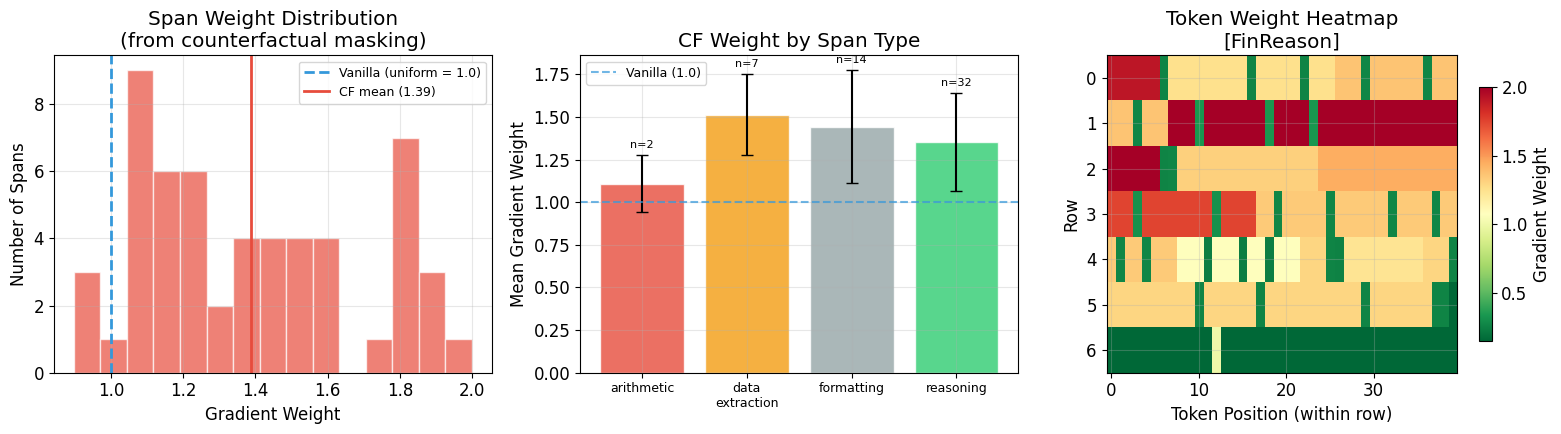

Key insight: Counterfactual masking reveals that spans containing
data extraction and arithmetic get 1.39x average weight,
while the vanilla baseline treats all spans equally at 1.0x.
The weight ratio between most and least important spans is 2.2x.


In [ ]:
# ── Visualize span weight distributions ──────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ── Left: Span weight distribution (histogram) ──
ax = axes[0]
all_weights = [sp['weight'] for ex in span_data for sp in ex['spans']]
ax.hist(all_weights, bins=15, color='#e74c3c', alpha=0.7, edgecolor='white')
ax.axvline(1.0, color='#3498db', linestyle='--', linewidth=2, label='Vanilla (uniform = 1.0)')
ax.axvline(np.mean(all_weights), color='#e74c3c', linestyle='-', linewidth=2,
           label=f'CF mean ({np.mean(all_weights):.2f})')
ax.set_xlabel('Gradient Weight')
ax.set_ylabel('Number of Spans')
ax.set_title('Span Weight Distribution\n(from counterfactual masking)')
ax.legend(fontsize=9)

# ── Middle: Weight by span type ──
ax = axes[1]
type_weights = {}
for ex in span_data:
    for sp in ex['spans']:
        t = sp['type']
        if t not in type_weights:
            type_weights[t] = []
        type_weights[t].append(sp['weight'])

type_names = sorted(type_weights.keys())
type_means = [np.mean(type_weights[t]) for t in type_names]
type_stds = [np.std(type_weights[t]) for t in type_names]
colors_bar = {'arithmetic': '#e74c3c', 'data_extraction': '#f39c12', 
              'reasoning': '#2ecc71', 'formatting': '#95a5a6'}
bar_colors = [colors_bar.get(t, '#95a5a6') for t in type_names]

bars = ax.bar(range(len(type_names)), type_means, yerr=type_stds, 
              color=bar_colors, alpha=0.8, capsize=4, edgecolor='white')
ax.axhline(1.0, color='#3498db', linestyle='--', linewidth=1.5, alpha=0.7, label='Vanilla (1.0)')
ax.set_xticks(range(len(type_names)))
ax.set_xticklabels([t.replace('_', '\n') for t in type_names], fontsize=9)
ax.set_ylabel('Mean Gradient Weight')
ax.set_title('CF Weight by Span Type')
ax.legend(fontsize=9)

# Add count labels
for i, (t, bar) in enumerate(zip(type_names, bars)):
    n = len(type_weights[t])
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + type_stds[i] + 0.03,
            f'n={n}', ha='center', va='bottom', fontsize=8)

# ── Right: Token-level weight heatmap for one example ──
ax = axes[2]
# Pick example with most varied weights
best_ex = max(span_data, key=lambda x: x['weight_stats']['std'])
tw = best_ex['token_weights']
weights_arr = np.array([t['weight'] for t in tw])

# Reshape into a grid for visualization
n_tokens = len(weights_arr)
cols = 40
rows = (n_tokens + cols - 1) // cols
padded = np.zeros(rows * cols)
padded[:n_tokens] = weights_arr
grid = padded.reshape(rows, cols)

im = ax.imshow(grid, cmap='RdYlGn_r', aspect='auto', vmin=0.15, vmax=2.0)
ax.set_xlabel('Token Position (within row)')
ax.set_ylabel('Row')
ax.set_title(f'Token Weight Heatmap\n[{best_ex["benchmark"]}]')
plt.colorbar(im, ax=ax, label='Gradient Weight', shrink=0.8)

plt.tight_layout()
plt.savefig('plots/cf_span_counterfactual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Key insight ──────────────────────────────────────────────────────────
print(f'Key insight: Counterfactual masking reveals that spans containing')
print(f'data extraction and arithmetic get {np.mean(all_weights):.2f}x average weight,')
print(f'while the vanilla baseline treats all spans equally at 1.0x.')
print(f'The weight ratio between most and least important spans is '
      f'{max(all_weights)/max(min(all_weights), 0.15):.1f}x.')

## 5. Results Summary

In [ ]:
# Summary table — all variants, both benchmarks
print('=' * 90)
print('Counterfactual vs Vanilla GRPO — Financial Reasoning (Qwen3-1.7B)')
print('=' * 90)
print(f'{"Method":<30} {"Best Step":>10} {"TAT-QA":>10} {"FinR-Med":>10} {"ΔFinR":>8} {"ΔTAT-QA":>8}')
print('-' * 90)
print(f'{"Base model":<30} {"—":>10} {BASE_TATQA:>10.2%} {BASE_FINMED:>10.2%} {"—":>8} {"—":>8}')

rows = [
    ('Vanilla GRPO', van_steps, van_med, van_tatqa),
    ('CF conserved (0.5–2.0)', cons_steps, cons_med, cons_tatqa),
    ('CF nocons (0.5–4.0)', cf1_steps, cf1_med, cf1_tatqa),
    ('CF nocons (0.15–2.0)', cf2_steps, cf2_med, cf2_tatqa),
]

for name, st, med, tatqa in rows:
    best_med_i = int(np.argmax(med))
    best_tatqa_i = int(np.argmax(tatqa))
    # Use the step that maximizes FinR-Med for reporting
    best_step = st[best_med_i]
    d_med = med[best_med_i] - BASE_FINMED
    d_tatqa = tatqa[best_tatqa_i] - BASE_TATQA
    print(f'{name:<30} {best_step:>10} {tatqa[best_tatqa_i]:>10.2%} {med[best_med_i]:>10.2%} {d_med:>+8.2%} {d_tatqa:>+8.2%}')

print('-' * 90)
# CF nocons2 vs Vanilla delta
cf_best_med = cf2_med.max()
cf_best_tatqa = cf2_tatqa.max()
van_best_med = van_med.max()
van_best_tatqa = van_tatqa.max()
print(f'{"CF nocons vs Vanilla":<30} {"":>10} {cf_best_tatqa - van_best_tatqa:>+10.2%} {cf_best_med - van_best_med:>+10.2%}')
print('=' * 90)

Counterfactual vs Vanilla GRPO — Financial Reasoning (Qwen3-1.7B)
Method                          Best Step     TAT-QA   FinR-Med    ΔFinR  ΔTAT-QA
------------------------------------------------------------------------------------------
Base model                              —     46.98%     39.52%        —        —
Vanilla GRPO                          500     47.94%     40.12%   +0.60%   +0.96%
CF conserved (0.5–2.0)                500     48.10%     41.53%   +2.01%   +1.12%
CF nocons (0.5–4.0)                   200     49.05%     41.73%   +2.21%   +2.07%
CF nocons (0.15–2.0)                  500     48.89%     42.94%   +3.42%   +1.91%
------------------------------------------------------------------------------------------
CF nocons vs Vanilla                          +0.95%     +2.82%


In [ ]:
# Full checkpoint-by-checkpoint table — all variants
configs = [
    ('CF nocons (0.15–2.0)', cf2_steps, cf2_med, cf2_tatqa),
    ('CF nocons (0.5–4.0)', cf1_steps, cf1_med, cf1_tatqa),
    ('CF conserved (0.5–2.0)', cons_steps, cons_med, cons_tatqa),
    ('Vanilla GRPO', van_steps, van_med, van_tatqa),
]

print(f'{"Config":<28} {"Bench":<12} {"100":>8} {"200":>8} {"300":>8} {"400":>8} {"500":>8}  {"Best":>8}')
print('=' * 100)

for name, st, med, tatqa in configs:
    for bench_name, vals in [('FinR Med', med), ('TAT-QA', tatqa)]:
        cells = []
        for s in [100, 200, 300, 400, 500]:
            idx = np.where(st == s)[0]
            if len(idx):
                cells.append(f'{vals[idx[0]]*100:.2f}%')
            else:
                cells.append('  N/A  ')
        best = f'{vals.max()*100:.2f}%' if len(vals) else 'N/A'
        print(f'{name:<28} {bench_name:<12} {cells[0]:>8} {cells[1]:>8} {cells[2]:>8} {cells[3]:>8} {cells[4]:>8}  {best:>8}')
    print()

Config                       Bench             100      200      300      400      500      Best
CF nocons (0.15–2.0)         FinR Med       40.12%   40.52%   40.32%   42.34%   42.94%    42.94%
CF nocons (0.15–2.0)         TAT-QA         47.78%   48.10%   48.73%   48.25%   48.89%    48.89%

CF nocons (0.5–4.0)          FinR Med       38.31%   41.73%   40.52%   40.32%   41.13%    41.73%
CF nocons (0.5–4.0)          TAT-QA         47.46%   47.14%   49.05%   46.51%   47.94%    49.05%

CF conserved (0.5–2.0)       FinR Med       40.73%   38.91%   38.51%   40.52%   41.53%    41.53%
CF conserved (0.5–2.0)       TAT-QA         47.78%   48.10%   47.30%   47.94%   47.62%    48.10%

Vanilla GRPO                 FinR Med       38.71%   37.10%   38.91%   38.10%   40.12%    40.12%
Vanilla GRPO                 TAT-QA         45.24%   47.78%   47.94%   47.94%   46.83%    47.94%

